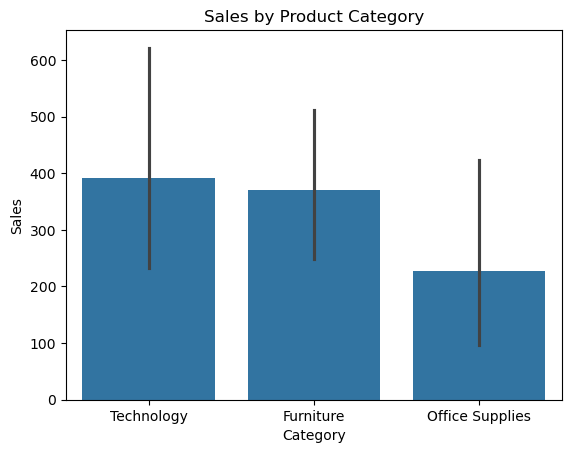

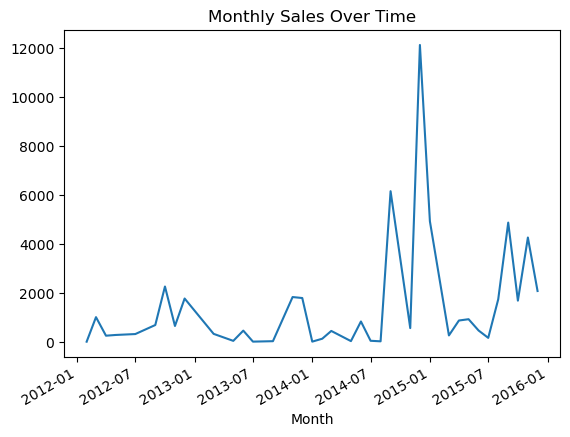

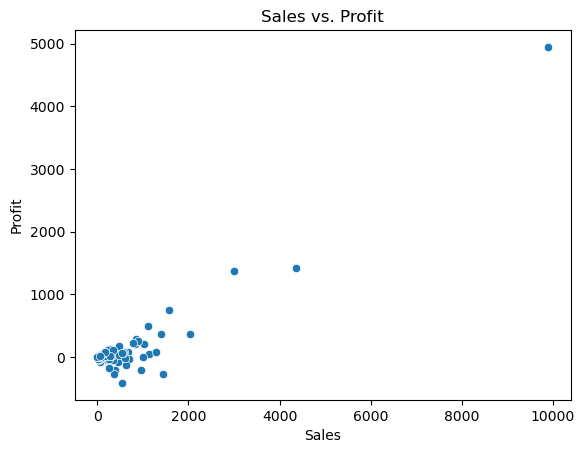

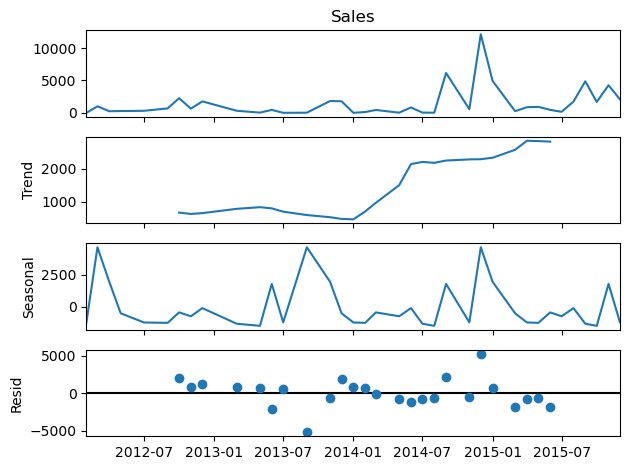

(np.float64(29.95), np.float64(12063.97), np.float64(-0.16262271039478665))

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

%matplotlib inline

df=pd.read_csv('/Users/Macbook/Documents/Jupyter/Global_Superstore.csv')
# df.head
# print(df.shape)
# df.info()
# df.describe()

# print(df.isnull().sum())
df.dropna(inplace=True)

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

# Top 10 prodcuts by sales
# top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
# print(top_products)

# Sales By Region
sales_by_region = df.groupby('Region')['Sales'].sum()
# print(sales_by_region)

# Correlation between sales and profit
correlation = df['Sales'].corr(df['Profit'])
# print(f"Correlation between Sales and Profit: {correlation}")

#Bar plot of sales by product category
sns.barplot(x='Category', y='Sales', data=df)
plt.title('Sales by Product Category')
plt.show()

# Create a new 'Month' colum from 'Order Date'
df['Month'] =df['Order Date'].dt.to_period('M')

#Calculate monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum()

#Ensure the index is in datetime format for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

#Plot Monthly Sales Over Time
monthly_sales.plot(kind='line')
plt.title('Monthly Sales Over Time')
plt.show()

# Scatter plot of Sales vs. Profit
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs. Profit')
plt.show()

# Pivot table for Sales by Region and Product Category
pivot_table = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')
                             
# Heatmap of Sales by Region and Product Category
# sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='Y1GnBU')
# plt.title('Sales by Region and Product Category')
# plt.show()

#Seasonal Decomposition of Time Series (monthly sales)
result = seasonal_decompose(monthly_sales, model='additive', period=12)
result.plot()
plt.show()

# Calculate total discount and total profit
total_discount = df['Discount'].sum()
total_profit =df['Profit'].sum()

# Convert 'Discount' and 'Profit' columns to numeric
df['Discount'] =pd.to_numeric(df['Discount'], errors='coerce')
df['Profit'] =pd.to_numeric(df['Profit'], errors='coerce')

# Calculate the correlation between discount and profit
discount_profit_correlation =df[['Discount', 'Profit']].corr().iloc[0, 1]

total_discount, total_profit, discount_profit_correlation


                             
# print(f"Total Sales: {total_sales}, Total Profit: {total_profit}")
